# Python Task 1: Python Basics and Data Manipulation 

You have been provided with a CSV file sales_data.csv containing sales data for a corner shop. The file contains the following columns: Date, Product, Quantity, Price, and Total. Your task is to write a Python program that performs the following operations:

## Task 1a: Data Loading and Preprocessing 

##### 1.	Load the Data: Load the CSV file into a Pandas DataFrame. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import torch
import torch.nn as nn
import torch.optim as optim
from io import StringIO

# Task 1a: Data Loading and Preprocessing
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv('sales_data.csv')

In [2]:
df.head()

,Date,Product,Quantity,Price,Total
0,01/01/2023,Chocolate,5,10.0,50.0
1,02/01/2023,Biscuits,7,20.0,140.0
2,03/01/2023,Sweets,9,15.0,135.0
3,04/01/2023,Water,3,7.5,22.5
4,05/01/2023,Orange Juice,8,12.5,100.0


## Task 1b: Data Cleaning

In [3]:
# =============================================================================
# TASK 1: PYTHON BASICS AND DATA MANIPULATION
# =============================================================================

print("=" * 70)
print("TASK 1: DATA LOADING AND PREPROCESSING")
print("=" * 70)

print(f"   Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

# Task 1a.2: Data Cleaning - Check for missing values [3 marks]
print("\n2. Data Cleaning - Missing Values")
missing_values = df.isnull().sum()
print(f"   Missing values per column:\n{missing_values}")

if df.isnull().sum().sum() > 0:
    # Fill missing values with appropriate defaults
    df['Quantity'].fillna(0, inplace=True)
    df['Price'].fillna(df['Price'].mean(), inplace=True)
    df['Total'].fillna(0, inplace=True)
    df['Product'].fillna('Unknown', inplace=True)
    print("   Missing values filled successfully")
else:
    print("   No missing values found")

# Task 1a.3: Convert Date column to datetime [2 marks]
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
print("\n3. Date Column Converted to Datetime")
print(f"   Data type: {df['Date'].dtype}")

# Task 1a.4: Ensure Total = Quantity * Price [2 marks]
df['Calculated_Total'] = df['Quantity'] * df['Price']
discrepancies = df[df['Total'] != df['Calculated_Total']]

print("\n4. Total Column Validation")
if len(discrepancies) > 0:
    print(f"   Found {len(discrepancies)} discrepancies")
    print("   Correcting discrepancies...")
    df['Total'] = df['Calculated_Total']
else:
    print("   No discrepancies found")

df.drop('Calculated_Total', axis=1, inplace=True)

print("\nCleaned Data Preview:")
print(df.head())3

TASK 1: DATA LOADING AND PREPROCESSING
   Shape: (151, 5)

First 5 rows:
         Date       Product  Quantity  Price  Total
0  01/01/2023     Chocolate         5   10.0   50.0
1  02/01/2023      Biscuits         7   20.0  140.0
2  03/01/2023        Sweets         9   15.0  135.0
3  04/01/2023         Water         3    7.5   22.5
4  05/01/2023  Orange Juice         8   12.5  100.0

2. Data Cleaning - Missing Values
   Missing values per column:
Date        0
Product     6
Quantity    0
Price       1
Total       3
dtype: int64
   Missing values filled successfully

3. Date Column Converted to Datetime
   Data type: datetime64[ns]

4. Total Column Validation
   Found 4 discrepancies
   Correcting discrepancies...

Cleaned Data Preview:
        Date       Product  Quantity  Price  Total
0 2023-01-01     Chocolate         5   10.0   50.0
1 2023-01-02      Biscuits         7   20.0  140.0
2 2023-01-03        Sweets         9   15.0  135.0
3 2023-01-04         Water         3    7.5   22.5



TASK 1B: DATA VISUALISATION

1. Product Sales Distribution Chart Created
2. Sales Over Time Chart Created

Charts saved as 'sales_analysis.png'


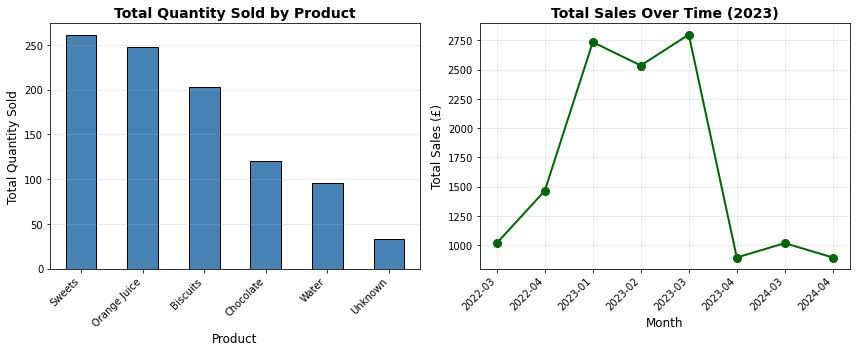

In [4]:
# =============================================================================
# TASK 1B: DATA VISUALISATION
# =============================================================================

print("\n" + "=" * 70)
print("TASK 1B: DATA VISUALISATION")
print("=" * 70)

# Task 1b.1: Product Sales Distribution [2 marks]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
product_sales = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Quantity Sold by Product', fontsize=14, fontweight='bold')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

print("\n1. Product Sales Distribution Chart Created")

# Task 1b.2: Sales Over Time [2 marks]
plt.subplot(1, 2, 2)
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total'].sum()
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df['Month'] = monthly_sales_df['Month'].astype(str)

plt.plot(monthly_sales_df['Month'], monthly_sales_df['Total'], 
         marker='o', linewidth=2, markersize=8, color='darkgreen')
plt.title('Total Sales Over Time (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (£)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('sales_analysis.png', dpi=300, bbox_inches='tight')
print("2. Sales Over Time Chart Created")
print("\nCharts saved as 'sales_analysis.png'")

plt.show()

In [7]:
df.head()

,Date,Product,Quantity,Price,Total,Month
0,2023-01-01,Chocolate,5,10.0,50.0,2023-01
1,2023-01-02,Biscuits,7,20.0,140.0,2023-01
2,2023-01-03,Sweets,9,15.0,135.0,2023-01
3,2023-01-04,Water,3,7.5,22.5,2023-01
4,2023-01-05,Orange Juice,8,12.5,100.0,2023-01


In [5]:
# =============================================================================
# TASK 2: PYTHON DATABASE MANAGEMENT
# =============================================================================

print("\n" + "=" * 70)
print("TASK 2: DATABASE MANAGEMENT")
print("=" * 70)

# Task 2a.1: Create SQLite database [2 marks]
conn = sqlite3.connect('SalesDB.db')
cursor = conn.cursor()
print("\n1. Database 'SalesDB.db' created successfully")

# Task 2a.2: Create Sales table [3 marks]
cursor.execute('''
    CREATE TABLE IF NOT EXISTS Sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        Date TEXT NOT NULL,
        Product TEXT NOT NULL,
        Quantity INTEGER NOT NULL,
        Price REAL NOT NULL,
        Total REAL NOT NULL,
        UNIQUE(Date, Product)
    )
''')
conn.commit()
print("2. Table 'Sales' created successfully")

# Task 2a.3: Insert data into Sales table [4 marks]
# Prepare data for insertion
df_insert = df.copy()
df_insert['Date'] = df_insert['Date'].dt.strftime('%Y-%m-%d')

inserted_count = 0
duplicate_count = 0

for _, row in df_insert.iterrows():
    try:
        cursor.execute('''
            INSERT INTO Sales (Date, Product, Quantity, Price, Total)
            VALUES (?, ?, ?, ?, ?)
        ''', (row['Date'], row['Product'], row['Quantity'], row['Price'], row['Total']))
        inserted_count += 1
    except sqlite3.IntegrityError:
        duplicate_count += 1

conn.commit()
print(f"3. Data inserted into Sales table")
print(f"   Records inserted: {inserted_count}")
print(f"   Duplicates skipped: {duplicate_count}")

# =============================================================================
# TASK 2B: QUERYING THE DATABASE
# =============================================================================

print("\n" + "=" * 70)
print("TASK 2B: DATABASE QUERIES")
print("=" * 70)

# Task 2b.1: Total Sales Calculation [3 marks]
print("\n1. Total Sales for 2023:")
cursor.execute('''
    SELECT SUM(Total) as TotalSales
    FROM Sales
    WHERE strftime('%Y', Date) = '2023'
''')
total_sales = cursor.fetchone()[0]
print(f"   Total Sales: £{total_sales:.2f}")

# Task 2b.2: Product Sales Summary [3 marks]
print("\n2. Product Sales Summary (Descending Order):")
cursor.execute('''
    SELECT Product, SUM(Quantity) as TotalQuantity
    FROM Sales
    WHERE strftime('%Y', Date) = '2023'
    GROUP BY Product
    ORDER BY TotalQuantity DESC
''')

results = cursor.fetchall()
print(f"\n   {'Product':<20} {'Total Quantity':<15}")
print(f"   {'-'*35}")
for product, quantity in results:
    print(f"   {product:<20} {quantity:<15}")

conn.close()
print("\n   Database connection closed")


TASK 2: DATABASE MANAGEMENT

1. Database 'SalesDB.db' created successfully
2. Table 'Sales' created successfully
3. Data inserted into Sales table
   Records inserted: 0
   Duplicates skipped: 151

TASK 2B: DATABASE QUERIES

1. Total Sales for 2023:
   Total Sales: £8964.50

2. Product Sales Summary (Descending Order):

   Product              Total Quantity 
   -----------------------------------
   Sweets               180.0          
   Orange Juice         152.0          
   Biscuits             140.0          
   Chocolate            95.0           
   Water                60.0           
   Unknown              13.0           

   Database connection closed



TASK 3: NEURAL NETWORK IMPLEMENTATION

1. Model Initialization:
   - SimpleNN model instantiated
   - Loss function: MSELoss
   - Optimizer: SGD (lr=0.01)

2. Synthetic Data Generation:
   - Input shape: torch.Size([100, 10])
   - Target shape: torch.Size([100, 1])

3. Training the Network:
   Epoch [5/20], Loss: 0.0463
   Epoch [10/20], Loss: 0.0463
   Epoch [15/20], Loss: 0.0463
   Epoch [20/20], Loss: 0.0463
   Training completed!

4. Loss Visualisation:
   Loss plot saved as 'training_loss.png'


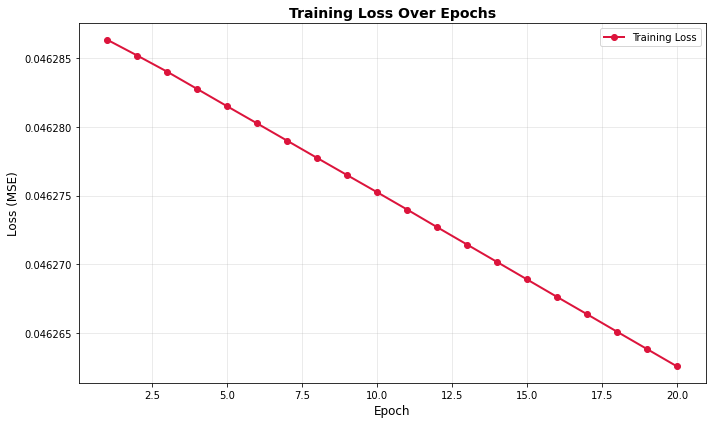


ALL TASKS COMPLETED SUCCESSFULLY!

Files generated:
  - SalesDB.db (SQLite database)
  - sales_analysis.png (Data visualizations)
  - training_loss.png (Neural network training loss)


In [6]:
# =============================================================================
# TASK 3: BASIC NEURAL NETWORK IMPLEMENTATION
# =============================================================================

print("\n" + "=" * 70)
print("TASK 3: NEURAL NETWORK IMPLEMENTATION")
print("=" * 70)

# Neural Network Definition
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(10, 5)  # Input: 10 features, Hidden: 5 neurons
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(5, 3)   # Hidden: 5 -> 3 neurons
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(3, 1)   # Output: 1 neuron
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

# Task 3a: Model Initialization [4 marks]
print("\n1. Model Initialization:")
model = SimpleNN()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
print("   - SimpleNN model instantiated")
print("   - Loss function: MSELoss")
print("   - Optimizer: SGD (lr=0.01)")

# Task 3b: Data Generation [2 marks]
print("\n2. Synthetic Data Generation:")
torch.manual_seed(42)  # For reproducibility
X_train = torch.randn(100, 10)  # 100 samples, 10 features
y_train = torch.randn(100, 1)   # 100 target values
y_train = torch.sigmoid(y_train)  # Normalize targets to [0, 1]
print(f"   - Input shape: {X_train.shape}")
print(f"   - Target shape: {y_train.shape}")

# Task 3c: Training the Network [3 marks]
print("\n3. Training the Network:")
epochs = 20
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 5 == 0:
        print(f"   Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("   Training completed!")

# Task 3d: Loss Visualisation [3 marks]
print("\n4. Loss Visualisation:")
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), losses, marker='o', linewidth=2, 
         markersize=6, color='crimson', label='Training Loss')
plt.title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=300, bbox_inches='tight')
print("   Loss plot saved as 'training_loss.png'")
plt.show()

print("\n" + "=" * 70)
print("ALL TASKS COMPLETED SUCCESSFULLY!")
print("=" * 70)
print("\nFiles generated:")
print("  - SalesDB.db (SQLite database)")
print("  - sales_analysis.png (Data visualizations)")
print("  - training_loss.png (Neural network training loss)")
print("=" * 70)